# QRC Circuit Gallery (Eval-3)

Displays all **8** quantum-reservoir circuit families registered in
`qrc_gene.quantum_reservoir.CIRCUIT_LIBRARY`, a from-scratch rewrite of the
circuit layer (see that module's docstring for the full rationale). This
replaces the previous 5-circuit-only version of this notebook.

**What changed and why:**

1. **The ensemble was silently broken.** `ensemble_search.py` sampled
   `circuit_config` values from the *old* `circuits.CIRCUIT_CONFIGS`
   (string keys like `"linear_linear"`), but `QRCConfig` validated
   against a *different*, newer int-keyed registry. Every QRC draw in a
   sweep raised `ValueError` before training anything — confirmed by
   running it — so `results_qrc_sweep.csv` in the repo root predates this
   mismatch and isn't comparable to anything produced now. This is fixed:
   there's one registry (`CIRCUIT_LIBRARY`) and everything reads from it.
2. **Two circuit families evaluated and added, as requested:**
   - The user-supplied `ReservoirCircuit_Nonlinear_GENE_Config1.qasm`
     circuit (reconstructed from `qasm_aer.ipynb`'s rendered diagram —
     see the caveats in the markdown cell below) → `qasm_reupload_dual_a`.
   - [MagriLab/Stability_QRC_GS](https://github.com/MagriLab/Stability_QRC_GS)'s
     `src/QRC/qrc.py` — turns out this was **already** ported here as
     configs 1–5 (`magri_*`, verified line-by-line against that repo's
     `unitaryblock.py`). What *hadn't* been ported were two block types
     that repo defines but never wires into any of its five configs:
     `Unitary_ReverseEnt` and `Unitary_C` → added as `magri_reverse_ent`
     and `magri_bidirectional`.
3. **All circuits rewritten from scratch** in `quantum_reservoir.py` — no
   function from the old `quantum_reservoir.py` or `circuits.py` is
   reused; `circuits.py` is now a thin deprecated compatibility shim.

Every reservoir step applies up to three labelled blocks after an initial
Hadamard layer:

| Block | Meaning |
|---|---|
| **H** | Hadamard layer → superposition (needed for interference/entanglement later) |
| **P** | *Recurrence* — re-encodes the reservoir's own previous measurement (all $2^n$ basis probabilities) as rotation angles. Genuine **quantum** memory, not a classical leaky average. Only the two `magri_*` recurrent configs use it. |
| **X** | Encodes the current (scaled) plasma-state input. |
| **A** | A fixed, never-trained random-angle entangling unitary — the reservoir's fixed internal dynamics. |

3 qubits are used below purely so the diagrams stay compact; the same code
runs at any `n_qubits` (see `01_QRC_GENE_Main.ipynb` /
`02_QRC_Ensemble_Configuration.ipynb`).


In [28]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
from qrc_gene.quantum_reservoir import QuantumReservoirComputer, QRCConfig, CIRCUIT_LIBRARY

N_QUBITS = 3   # kept small so the circuit diagrams stay readable
DIM = 3        # plasma-state dimension (matches the main notebook)

CIRCUIT_KEYS = list(CIRCUIT_LIBRARY.keys())
print(f"{len(CIRCUIT_KEYS)} circuits registered:")
for k in CIRCUIT_KEYS:
    print(f"  {k}")


8 circuits registered:
  magri_full_fullsym
  magri_linear
  magri_linear_x2
  magri_full_x2
  magri_feature_x2
  magri_reverse_ent
  magri_bidirectional
  qasm_reupload_dual_a


## Evaluation 1 — the user-supplied QASM circuit

The uploaded `qasm_aer.ipynb` loads `ReservoirCircuit_Nonlinear_GENE_Config1.qasm`
from disk and draws + simulates it, but **the `.qasm` file itself was not part of
the upload** — only the notebook that loads and renders it was. The circuit was
therefore reconstructed from the *rendered circuit diagram* saved in that
notebook's own output cell (a 5-qubit, 54-deep, 109-gate diagram), not from the
gate-level source. What's clearly visible in that image and reproduced faithfully
below:

- **H** on all 5 qubits.
- A **repeated linear RY+CNOT ladder** walking the qubit chain, applied **5
  times in a row** (once per qubit, i.e. depth scales with qubit count) — this
  is the "data re-uploading" pattern (Pérez-Salinas et al., 2020): re-injecting
  the same classical input at multiple points in a fixed-depth circuit increases
  the feature map's expressivity without adding qubits.
- Two **symmetric fully-entangled RY–CNOT–RY** sandwich blocks applied
  back-to-back with the *same* fixed angles both times — i.e. the reservoir's
  fixed block **A** run twice in immediate succession, deepening entanglement
  beyond what any of the five `magri_*` configs do (they all apply `A` once).
- Measurement on all 5 qubits (handled here via exact `Statevector`
  probabilities rather than shots, same as everywhere else in this codebase —
  physically equivalent, no shot noise).

What's genuinely uncertain from an image alone: the *exact* wraparound wiring of
the repeated ladder at the chain's ends. `apply_chain_ladder` below reproduces
the same bounce-back-at-the-ends convention used everywhere else in this module
(`Unitary4`'s convention) rather than guessing at a different one, and is applied
`n_qubits` times to match the "repeats scale with qubit count" pattern seen in
the image. **If the original `.qasm` file becomes available, swap this entry for
an exact `qiskit.qasm3.loads(...)` import** — trivial once the file exists, but
not guessable from a rendered image alone.

**Verdict — good fit, added as `qasm_reupload_dual_a`:** the repeated-encoding +
doubled-entangling-block design is a legitimate way to enrich the feature map
without more qubits, and depth/gate-count numbers below confirm it's
meaningfully deeper than every `magri_*` config at the same qubit count. Two
caveats worth weighing before making it a default: (1) it has **no P
(recurrence) block**, so its only memory mechanism is the classical leaky
update `epsilon_q` — same as configs 3–7, but less memory than the two
recurrent `magri_*` configs; (2) being the deepest circuit in the library, it's
also the most expensive to simulate classically per step (see the cost
comparison below) — a real consideration since a full sweep re-simulates every
config from scratch. Since the circuit itself is fixed (never trained), depth
doesn't create a barren-plateau/trainability problem here the way it would for
a variational ansatz — the concern is purely simulation cost, not learnability.


## Evaluation 2 — MagriLab `Stability_QRC_GS/src/QRC/qrc.py`

Cloning that repo and diffing its `qrc.py` / `unitaryblock.py` against what was
already in this project's `quantum_reservoir.py` shows **configs 1–5
(`magri_*` below) are already a faithful port** of that file's five
`gen_quantumcircuit` configurations — built from its `Unitary4`,
`Unitary_FullyEnt`, `Unitary_FullyEntSym` and `Unitary_Feature` blocks. So "add
it to the ensemble" was largely already true architecturally; the actual gap
(fixed here) was that `ensemble_search.py` couldn't reach any of them due to
the key-mismatch bug described above.

What genuinely *was* missing: `unitaryblock.py` also defines
`Unitary_ReverseEnt` and `Unitary_C` — but **neither is used by any of the five
named configs in `qrc.py`**, i.e. they're dead code in the upstream repo too.
Both are ported here as new, real ensemble members:

- **`magri_reverse_ent`** (`Unitary_ReverseEnt`): a forward nearest-neighbour
  CNOT chain, an RY layer, then the *same* chain applied again but walked in
  reverse iteration order. Because CNOTs on overlapping qubit pairs don't
  commute through the intervening rotations, forward-then-backward produces a
  genuinely different entangled state than forward-twice would.
- **`magri_bidirectional`** (`Unitary_C`): each qubit gets its own RY, then
  connects to *both* neighbours (not just the next one) as the sweep passes it
  — denser local connectivity than the plain chain ladder, still $O(n)$ gates
  (no all-to-all cost).


## All 8 circuit templates

Each diagram is the **parameterised template** built once per reservoir
instance: `P` / `X` are live Qiskit `Parameter`s rebound every timestep via
`assign_parameters` (fast); `A` is baked in as fixed numbers immediately since
it never changes for a given reservoir instance. Barriers mark block
boundaries.


magri_full_fullsym: H -> P:chain-ladder (recurrent) -> X:dense-entangle -> A:dense-entangle-mirrored
  source: Stability_QRC_GS qrc.py config 1 (Unitary4 -> Unitary_FullyEnt -> Unitary_FullyEntSym)
  recurrent=True   N_units=2^3=8   gates=34   depth=26


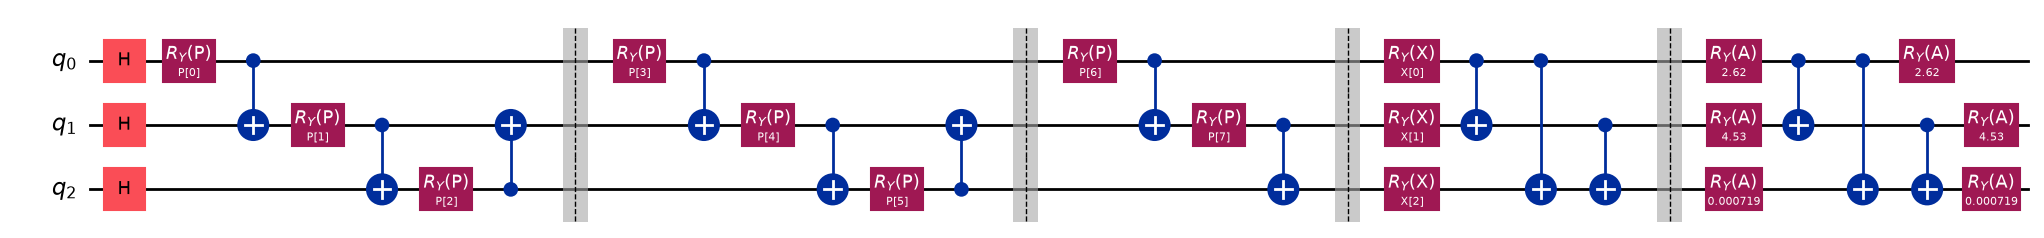

In [29]:
cfg = QRCConfig(n_qubits=N_QUBITS, dim=DIM, circuit_config="magri_full_fullsym", seed=1)
qrc = QuantumReservoirComputer(cfg)
spec = qrc.spec
print(f"magri_full_fullsym: {spec.description}")
print(f"  source: {spec.source}")
print(f"  recurrent={qrc.recurrent}   N_units=2^{N_QUBITS}={qrc.N_units}   "
      f"gates={qrc.template.size()}   depth={qrc.template.depth()}")
qrc.template.draw(output="mpl", fold=-1)


magri_linear: H -> P:chain-ladder (recurrent) -> X:chain-ladder -> A:chain-ladder
  source: Stability_QRC_GS qrc.py config 2 (Unitary4 x3)
  recurrent=True   N_units=2^3=8   gates=31   depth=29


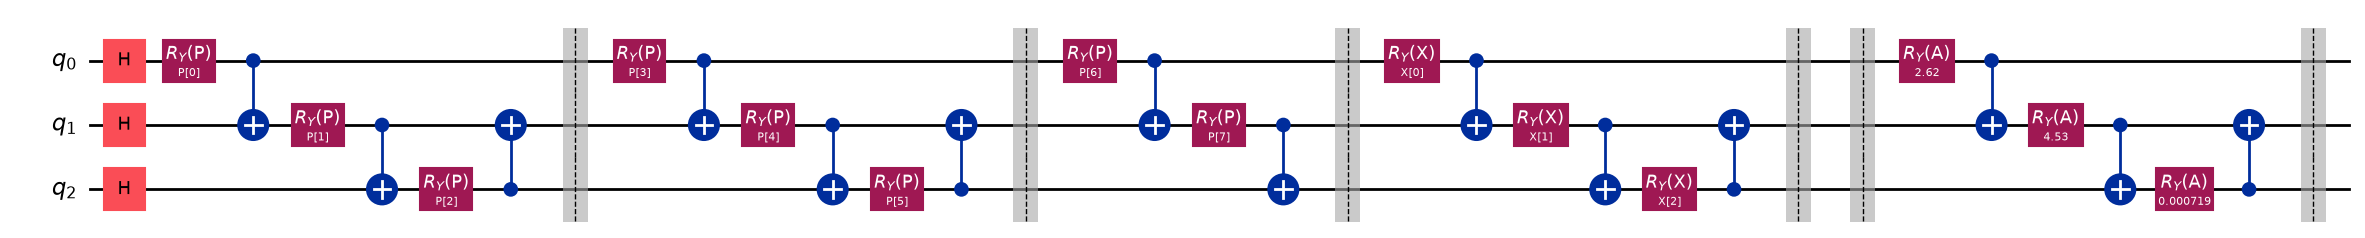

In [30]:
cfg = QRCConfig(n_qubits=N_QUBITS, dim=DIM, circuit_config="magri_linear", seed=1)
qrc = QuantumReservoirComputer(cfg)
spec = qrc.spec
print(f"magri_linear: {spec.description}")
print(f"  source: {spec.source}")
print(f"  recurrent={qrc.recurrent}   N_units=2^{N_QUBITS}={qrc.N_units}   "
      f"gates={qrc.template.size()}   depth={qrc.template.depth()}")
qrc.template.draw(output="mpl", fold=-1)


magri_linear_x2: H -> X:chain-ladder x2 -> A:chain-ladder
  source: Stability_QRC_GS qrc.py config 3 (Unitary4 x3, no P)
  recurrent=False   N_units=2^3=8   gates=21   depth=19


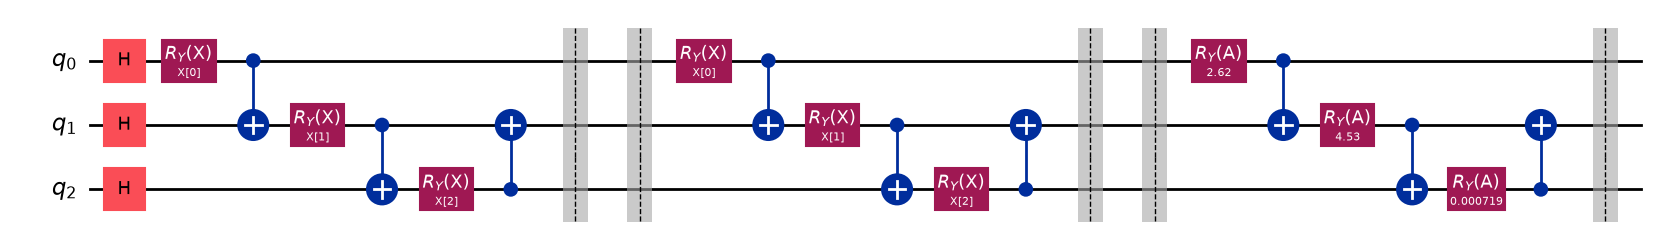

In [31]:
cfg = QRCConfig(n_qubits=N_QUBITS, dim=DIM, circuit_config="magri_linear_x2", seed=1)
qrc = QuantumReservoirComputer(cfg)
spec = qrc.spec
print(f"magri_linear_x2: {spec.description}")
print(f"  source: {spec.source}")
print(f"  recurrent={qrc.recurrent}   N_units=2^{N_QUBITS}={qrc.N_units}   "
      f"gates={qrc.template.size()}   depth={qrc.template.depth()}")
qrc.template.draw(output="mpl", fold=-1)


magri_full_x2: H -> X:dense-entangle x2 -> A:dense-entangle-mirrored
  source: Stability_QRC_GS qrc.py config 4 (Unitary_FullyEnt x2 -> Unitary_FullyEntSym)
  recurrent=False   N_units=2^3=8   gates=24   depth=14


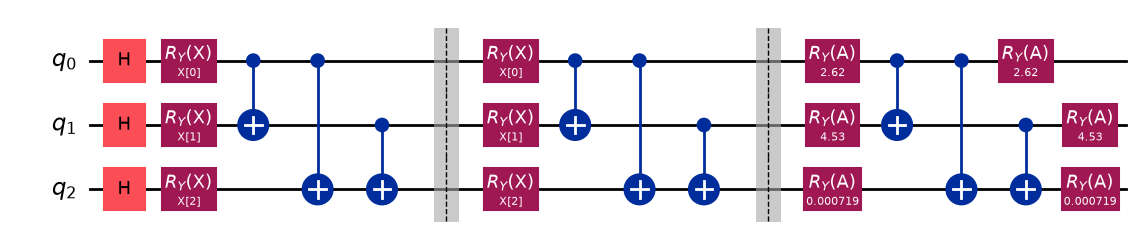

In [32]:
cfg = QRCConfig(n_qubits=N_QUBITS, dim=DIM, circuit_config="magri_full_x2", seed=1)
qrc = QuantumReservoirComputer(cfg)
spec = qrc.spec
print(f"magri_full_x2: {spec.description}")
print(f"  source: {spec.source}")
print(f"  recurrent={qrc.recurrent}   N_units=2^{N_QUBITS}={qrc.N_units}   "
      f"gates={qrc.template.size()}   depth={qrc.template.depth()}")
qrc.template.draw(output="mpl", fold=-1)


magri_feature_x2: H -> X:pairwise-product x2 -> A:chain-ladder
  source: Stability_QRC_GS qrc.py config 5 (Unitary_Feature x2 -> Unitary4)
  recurrent=False   N_units=2^3=8   gates=33   depth=27


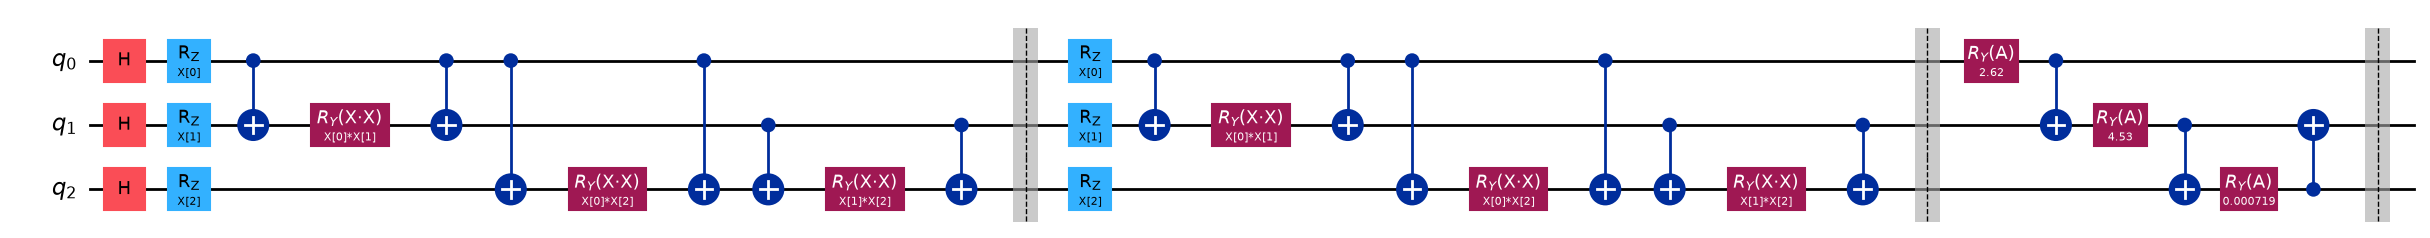

In [33]:
cfg = QRCConfig(n_qubits=N_QUBITS, dim=DIM, circuit_config="magri_feature_x2", seed=1)
qrc = QuantumReservoirComputer(cfg)
spec = qrc.spec
print(f"magri_feature_x2: {spec.description}")
print(f"  source: {spec.source}")
print(f"  recurrent={qrc.recurrent}   N_units=2^{N_QUBITS}={qrc.N_units}   "
      f"gates={qrc.template.size()}   depth={qrc.template.depth()}")
qrc.template.draw(output="mpl", fold=-1)


magri_reverse_ent: H -> X:reverse-sandwich x2 -> A:chain-ladder
  source: Stability_QRC_GS unitaryblock.py Unitary_ReverseEnt (defined but unused by any qrc.py config) [NEW to ensemble]
  recurrent=False   N_units=2^3=8   gates=23   depth=17


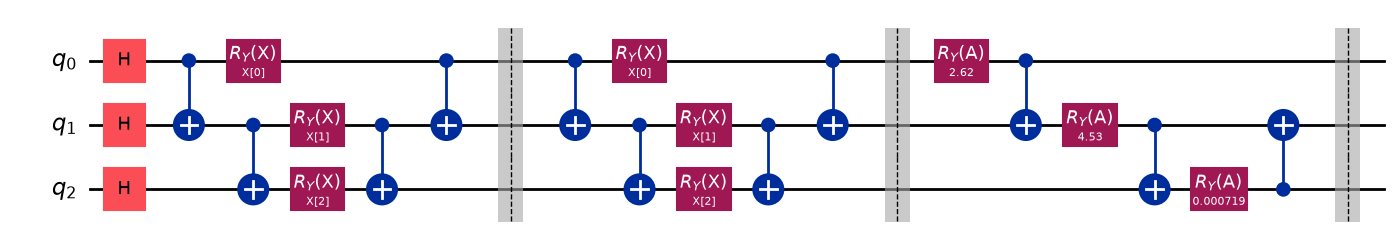

In [34]:
cfg = QRCConfig(n_qubits=N_QUBITS, dim=DIM, circuit_config="magri_reverse_ent", seed=1)
qrc = QuantumReservoirComputer(cfg)
spec = qrc.spec
print(f"magri_reverse_ent: {spec.description}")
print(f"  source: {spec.source}")
print(f"  recurrent={qrc.recurrent}   N_units=2^{N_QUBITS}={qrc.N_units}   "
      f"gates={qrc.template.size()}   depth={qrc.template.depth()}")
qrc.template.draw(output="mpl", fold=-1)


magri_bidirectional: H -> X:bidirectional-linear x2 -> A:dense-entangle-mirrored
  source: Stability_QRC_GS unitaryblock.py Unitary_C (defined but unused by any qrc.py config) [NEW to ensemble]
  recurrent=False   N_units=2^3=8   gates=26   depth=20


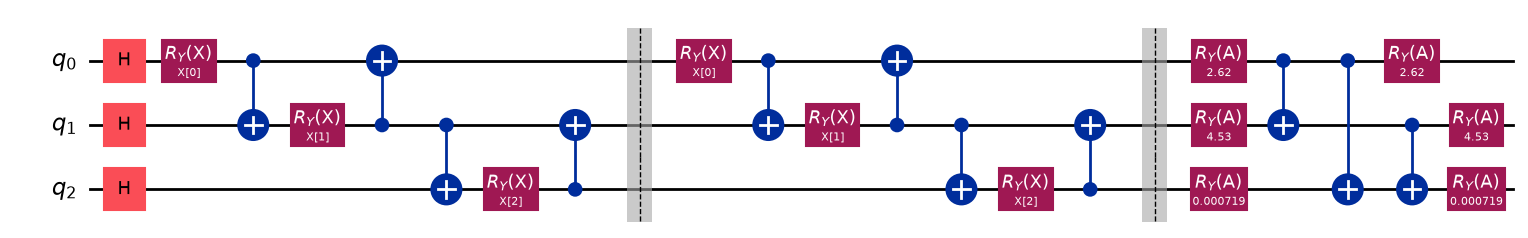

In [35]:
cfg = QRCConfig(n_qubits=N_QUBITS, dim=DIM, circuit_config="magri_bidirectional", seed=1)
qrc = QuantumReservoirComputer(cfg)
spec = qrc.spec
print(f"magri_bidirectional: {spec.description}")
print(f"  source: {spec.source}")
print(f"  recurrent={qrc.recurrent}   N_units=2^{N_QUBITS}={qrc.N_units}   "
      f"gates={qrc.template.size()}   depth={qrc.template.depth()}")
qrc.template.draw(output="mpl", fold=-1)


qasm_reupload_dual_a: H -> X:chain-ladder x n_qubits (data re-upload) -> A:dense-entangle-mirrored x2
  source: Reconstructed from user-supplied ReservoirCircuit_Nonlinear_GENE_Config1.qasm (via qasm_aer.ipynb's rendered circuit diagram -- see module docstring) [NEW to ensemble]
  recurrent=False   N_units=2^3=8   gates=39   depth=29


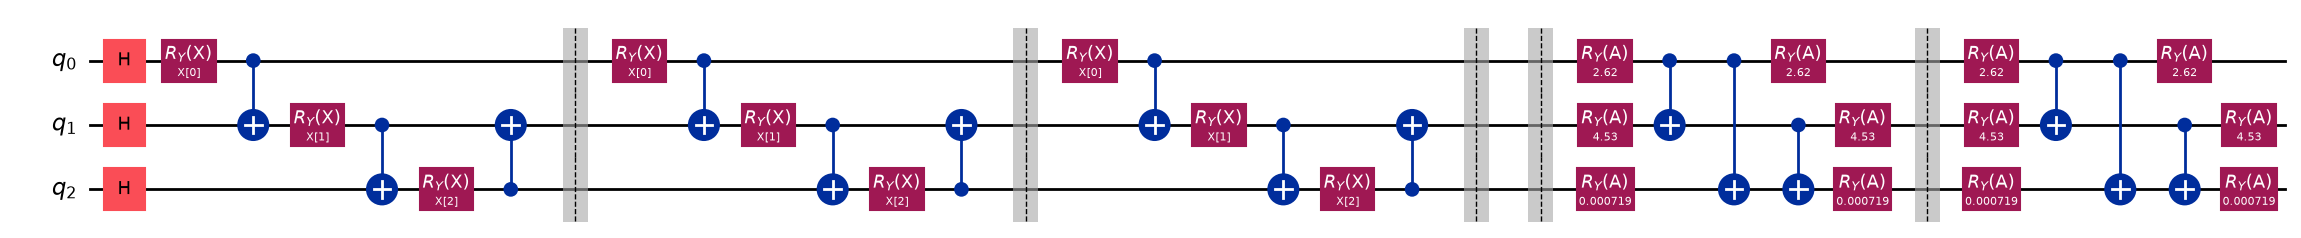

In [36]:
cfg = QRCConfig(n_qubits=N_QUBITS, dim=DIM, circuit_config="qasm_reupload_dual_a", seed=1)
qrc = QuantumReservoirComputer(cfg)
spec = qrc.spec
print(f"qasm_reupload_dual_a: {spec.description}")
print(f"  source: {spec.source}")
print(f"  recurrent={qrc.recurrent}   N_units=2^{N_QUBITS}={qrc.N_units}   "
      f"gates={qrc.template.size()}   depth={qrc.template.depth()}")
qrc.template.draw(output="mpl", fold=-1)


## What actually gets simulated: fully-bound examples

The templates above have symbolic `P`/`X` parameters. At runtime every value is
substituted with real numbers (the reservoir's previous measured probabilities
for `P`, the current scaled plasma state for `X`) via
`QuantumReservoirComputer.bind()` — this is the exact circuit object passed to
Qiskit's `Statevector.from_instruction` every single timestep. Shown here with
illustrative example values (`example_bound_circuit`) for one recurrent config
and one non-recurrent config, so both circuit shapes are visible.


magri_linear (recurrent) -- bound example:


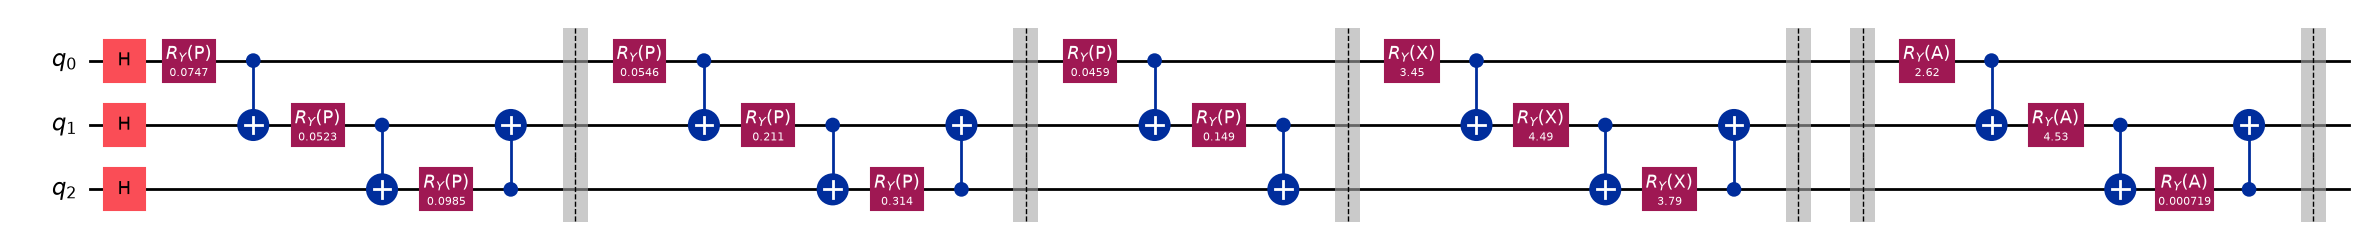

In [37]:
cfg1 = QRCConfig(n_qubits=N_QUBITS, dim=DIM, circuit_config="magri_linear", seed=1)
qrc1 = QuantumReservoirComputer(cfg1)
bound_qc = qrc1.example_bound_circuit(seed=0)
print("magri_linear (recurrent) -- bound example:")
bound_qc.draw(output="mpl", fold=-1)


qasm_reupload_dual_a (non-recurrent) -- bound example:


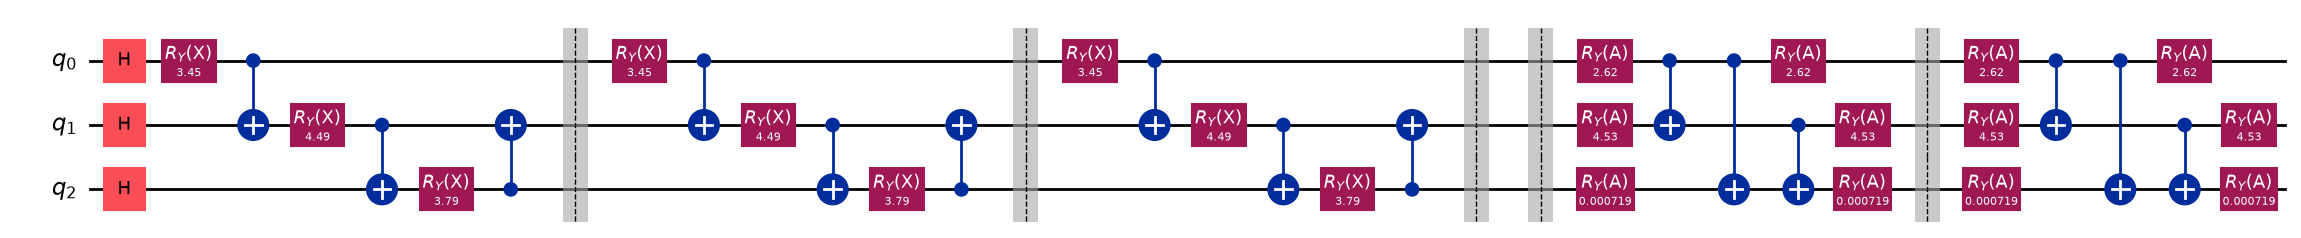

In [38]:
cfg2 = QRCConfig(n_qubits=N_QUBITS, dim=DIM, circuit_config="qasm_reupload_dual_a", seed=1)
qrc2 = QuantumReservoirComputer(cfg2)
bound_qc2 = qrc2.example_bound_circuit(seed=0)
print("qasm_reupload_dual_a (non-recurrent) -- bound example:")
bound_qc2.draw(output="mpl", fold=-1)


## Cost comparison across configs and qubit counts

The two recurrent `magri_*` configs cost $O(2^{n\_qubits})$ *extra* gates for
the `P` block (it re-encodes the full $2^n$-dimensional probability vector
every step), so their circuit size grows far faster with qubit count than the
other six. `qasm_reupload_dual_a` doesn't have that exponential blowup, but its
repeats-scale-with-`n_qubits` design still makes it the most expensive of the
non-recurrent configs (quadratic in `n_qubits`, vs. linear for the others).


In [39]:
rows = []
for key in CIRCUIT_KEYS:
    for nq in [3, 4, 5, 6, 7]:
        cfg = QRCConfig(n_qubits=nq, dim=DIM, circuit_config=key, seed=1)
        qrc = QuantumReservoirComputer(cfg)
        rows.append({"circuit": key, "recurrent": qrc.recurrent, "n_qubits": nq,
                      "N_units": qrc.N_units, "gates": qrc.template.size(),
                      "depth": qrc.template.depth()})
df = pd.DataFrame(rows)
df.pivot(index="circuit", columns="n_qubits", values="gates")


n_qubits,3,4,5,6,7
circuit,,,,,
magri_bidirectional,26,37,49,62,76
magri_feature_x2,33,35,37,39,41
magri_full_fullsym,34,58,100,176,318
magri_full_x2,24,35,49,66,86
magri_linear,31,49,83,149,279
magri_linear_x2,21,23,25,27,29
magri_reverse_ent,23,29,35,41,47
qasm_reupload_dual_a,39,55,73,93,115


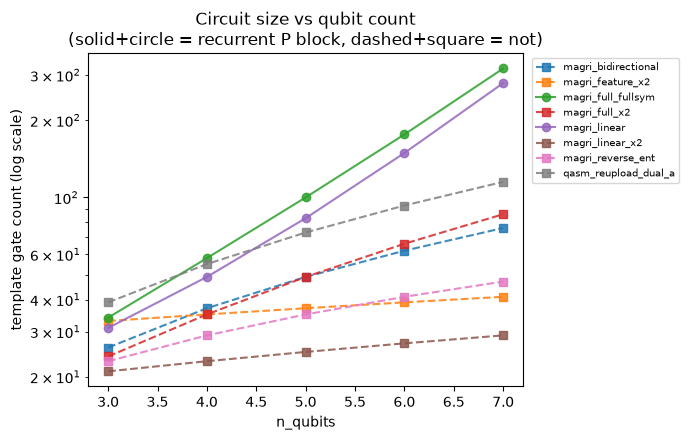

In [40]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for key, grp in df.groupby("circuit"):
    style = "-o" if grp["recurrent"].iloc[0] else "--s"
    ax.plot(grp["n_qubits"], grp["gates"], style, label=key, alpha=0.85)
ax.set_yscale("log")
ax.set_xlabel("n_qubits"); ax.set_ylabel("template gate count (log scale)")
ax.set_title("Circuit size vs qubit count\n(solid+circle = recurrent P block, dashed+square = not)")
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1.01, 1.0))
plt.tight_layout(); plt.show()


## Summary

| Circuit | Blocks | Recurrent | Source | Relative cost |
|---|---|---|---|---|
| `magri_full_fullsym` | P:chain-ladder, X:dense-entangle, A:dense-entangle-mirrored | Yes | Stability_QRC_GS config 1 | High, grows fastest with qubits |
| `magri_linear` | P:chain-ladder, X:chain-ladder, A:chain-ladder | Yes | Stability_QRC_GS config 2 | High, grows fastest with qubits |
| `magri_linear_x2` | X:chain-ladder x2, A:chain-ladder | No | Stability_QRC_GS config 3 | Low |
| `magri_full_x2` | X:dense-entangle x2, A:dense-entangle-mirrored | No | Stability_QRC_GS config 4 | Medium |
| `magri_feature_x2` | X:pairwise-product x2, A:chain-ladder | No | Stability_QRC_GS config 5 | Medium (nonlinear encoding) |
| `magri_reverse_ent` | X:reverse-sandwich x2, A:chain-ladder | No | Stability_QRC_GS `unitaryblock.py` (unused upstream) | Low–medium **[NEW]** |
| `magri_bidirectional` | X:bidirectional-linear x2, A:dense-entangle-mirrored | No | Stability_QRC_GS `unitaryblock.py` (unused upstream) | Medium **[NEW]** |
| `qasm_reupload_dual_a` | X:chain-ladder x n_qubits, A:dense-entangle-mirrored x2 | No | Reconstructed from user's QASM notebook diagram | Medium–high, grows fastest of the non-recurrent group **[NEW]** |

Use the two recurrent `magri_*` configs when the richest possible reservoir
memory matters more than runtime (small qubit counts). The other six scale far
better for larger `n_qubits` and are good defaults for the ensemble sweep in
`02_QRC_Ensemble_Configuration.ipynb` — which now actually reaches all 8 of
them (see the changelog note at the top of `ensemble_search.py`).
